In [1]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
import analysis_functional as a

PyHEADTAIL v1.16.5


# 1D sweep

In [4]:
enlargements = ['none', 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2]
#enlargements = ['none', 0.4, 0.6, 0.8, 1, 1.5, 2]
Qxs = []
Qys = []
qxs = []
qys = []
survivor_masks = []
for en in enlargements:#
    res = a.load_simulation(f'data/sweep_size_offset/{en}.h5')
    Qx, Qy = a.get_tunes(res.x, res.y, res.px, res.py, res.twiss_df_at_mon, res.survivor_mask)
    Qxs.append(Qx)
    Qys.append(Qy)
    qxs.append(res.qx)
    qys.append(res.qy)
    #print(en)
    #print(np.sum(res.survivor_mask))
    survivor_masks.append(res.survivor_mask)
    """
    if en != 'none':
        fig, ax = plt.subplots(figsize=(10,4))
        ax.plot(res.aper_df['s'], res.aper_df['x'].values + res.aper_df['Lx'].values, c='k', label='Beam Pipe')
        ax.plot(res.aper_df['s'], res.aper_df['x'].values - res.aper_df['Lx'].values, c='k')
        ax.plot(res.aper_df['s'], res.beam_df['x0'].values + res.beam_df['sigma_x'].values, c='r', ls='--', label=r'$1\sigma$ (from Twiss)')
        ax.plot(res.aper_df['s'], res.beam_df['x0'].values - res.beam_df['sigma_x'].values, c='r', ls='--',)
        ax.plot(res.aper_df['s'], res.beam_df['x0'].values, c='r', label='Closed orbit')
        ax.set_xlabel('$s$ / m')
        ax.set_ylabel('$x$ / m')
        fig.suptitle(en)
        plt.show()"""

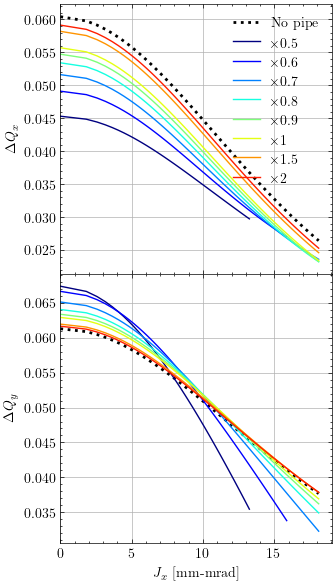

In [6]:
gamx = 0.13112848113527537 # gamma at 0
Jx_max = gamx * 0.05**2
Jx = np.linspace(0, Jx_max, 100)

fig, axs = plt.subplots(2, figsize=(3.5,7), sharex=True)
fig.subplots_adjust(hspace=0)

cmap = plt.get_cmap('jet')
n_lines = len(enlargements[1:])

axs[1].set_xlabel(r'$J_x$ [mm-mrad]')# ($J_y=0.004$ [mm-mrad])')
axs[0].set_ylabel(r'$\Delta Q_x$')
axs[1].set_ylabel(r'$\Delta Q_y$')

axs[0].plot(np.sqrt(Jx*1e6), qxs[0]-Qxs[0], c='k', lw=2, ls=':', label=f'No pipe')
axs[1].plot(np.sqrt(Jx*1e6), qys[0]-Qys[0], c='k', lw=2, ls=':', label=f'No pipe')
for i, en in enumerate(enlargements[1: ]):
    if en==10:
        color='k'
    else:
        color = cmap(i / n_lines)
    axs[0].plot(np.sqrt((Jx*1e6)[survivor_masks[i+1]]), qxs[i+1]-Qxs[i+1], lw=1, color=color, label=fr'$\times${en}')
    axs[1].plot(np.sqrt((Jx*1e6)[survivor_masks[i+1]]), qys[i+1]-Qys[i+1], lw=1, color=color, label=fr'$\times${en}')
axs[0].set_xlim(0)
axs[1].set_xlim(0)
#axs[0].set_ylim(0)
#axs[1].set_ylim(0)
axs[0].legend()
axs[0].grid()
axs[1].grid()
plt.savefig('action-tune.pdf', bbox_inches='tight')

In [11]:
0.35660305783564805*1e-8*1e6

0.0035660305783564807

# 2D sweep

In [20]:
enlargements = ['none', 1, 2,]
enlargements = ['none', 1]
Qxs = []
Qys = []
qxs = []
qys = []
survivor_masks= []
for en in enlargements:#
    res = a.load_simulation(f'data/sweep_2d/{en}.h5')
    Qx, Qy = a.get_tunes(res.x, res.y, res.px, res.py, res.twiss_df_at_mon, res.survivor_mask)
    Qxs.append(Qx)
    Qys.append(Qy)
    qxs.append(res.qx)
    qys.append(res.qy)
    survivor_masks.append(res.survivor_mask)
    

Text(0.5, 1.0, 'No beam pipe (top)\n Beam pipe (bottom)')

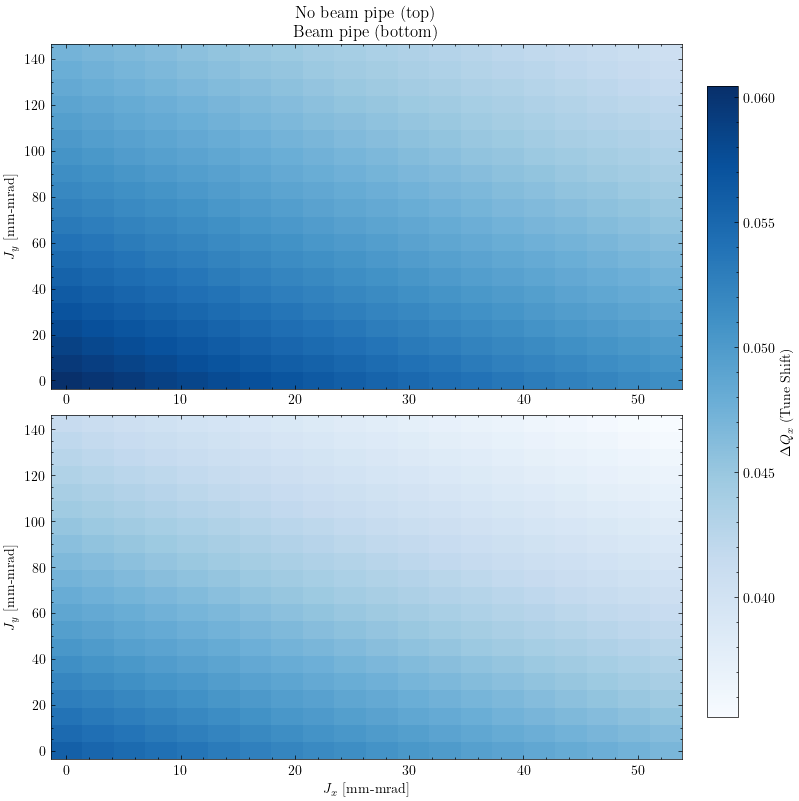

In [27]:
gamx = 0.13112848113527537 # gamma at 0
gamy = 0.35660305783564805

Jx_max = gamx * 0.02**2
Jy_max = gamy * 0.02**2
Jx = np.linspace(0, Jx_max, 20)
Jy = np.linspace(0, Jy_max, 20)
XX, YY = np.meshgrid(Jx, Jy)

all_dqx = [qxs[i] - Qxs[i].reshape(20,20) for i in range(len(enlargements))]
vmin = np.nanmin(all_dqx)
vmax = np.nanmax(all_dqx)

fig, axs = plt.subplots(len(enlargements), 1, figsize=(8, 4 * len(enlargements)), constrained_layout=True)

if len(enlargements) == 1: axs = [axs]

for i, en in enumerate(enlargements):
    qx_full = np.full(len(survivor_masks[i]), np.nan)
    qx_full[survivor_masks[i]] = Qxs[i] 
    QX_grid = qx_full.reshape(20, 20)
    
    qy_full = np.full(len(survivor_masks[i]), np.nan)
    qy_full[survivor_masks[i]] = Qys[i] 
    QY_grid = qy_full.reshape(20, 20)
    
    dQx = qxs[i] - QX_grid
    mesh = axs[i].pcolormesh(XX * 1e6, YY * 1e6, dQx, 
                             shading='auto', cmap='Blues', 
                             vmin=vmin, vmax=vmax)
    
    axs[i].set_ylabel('$J_y$ [mm-mrad]')

axs[-1].set_xlabel('$J_x$ [mm-mrad]')

cbar = fig.colorbar(mesh, ax=axs, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label(r'$\Delta Q_x$ (Tune Shift)')
axs[0].set_title('No beam pipe (top)\n Beam pipe (bottom)')

In [19]:
print(np.sum(res.survivor_mask))

400


In [ ]:
qx_full = np.full(len(survivor_mask), np.nan)
qx_full[survivor_mask] = qx_results 
QX_grid = qx_full.reshape(20, 20)